# Question 3
-------
In this exercise you will compare three image denoising methods:
- Gaussian linear filtering 
- Bilateral filtering
Use a standard grayscale test image (for example cameraman)


## Setup 
-----
1. Load a grayscale image $f$ and scale intensities to the interval $[0, 1]$
2. Create a noisy observation 
$$g=f+\eta$$
$$\eta[n, m]\approx \mathcal{N}(0, \sigma^2)$$

for two noise levels, for example $\sigma \in \{0.05, 0.10\}$. To this end, use the `randn` function for noise generation.



In [1]:
# Imports
import numpy as np
import cv2
from scipy.signal import convolve2d
import matplotlib.pyplot as plt

In [2]:
# Setup
# 1. Load the clean image (f)
f = cv2.imread('Cameraman.png', cv2.IMREAD_GRAYSCALE)
f = f.astype(np.float64) / 255.0  # Scale to [0, 1]

# 2. Define noise levels
sigmaNoise = [0.05, 0.10]

# Smoothening Strength
sigmaG = 1.2

# 3. Generate noise (eta)
# Using the same shape as f
eta1 = sigmaNoise[0] * np.random.randn(*f.shape)
eta2 = sigmaNoise[1] * np.random.randn(*f.shape)

# 4. Create noisy observations (g)
g1 = f + eta1
g2 = f + eta2

# Note: We should clip the results to [0, 1] for visualization
g1Clipped = np.clip(g1, 0, 1)
g2Clipped = np.clip(g2, 0, 1)


## Gaussian Linear Filtering
--------
Implement Gaussian smoothing using a two-dimensional Gaussian kernel

$$h[n, m]\propto e^{-\frac{m^2+n^2}{2\sigma^2_g}}$$

You may use MATLAB/NumPy functions to generate the impulse response of the Gaussian filter. Choose the kernel size as a function of $\sigma_g$ (for example, $6\sigma_g + 1$) and apply the filter using two-dimensional convolution.



In [3]:
def ApplyGaussianFilter(noisy_img, sigma_g):
    # Determine kernel size (6*sigma + 1) and make it odd
    kSize = int(6 * sigma_g + 1)
    
    if kSize % 2 == 0: 
        kSize += 1
    
    # Create a 1D coordinate array centered at 0
    ax = np.linspace(-(kSize - 1) / 2, (kSize - 1) / 2, kSize)
    
    # Generate 1D Gaussian and take outer product for 2D
    gauss1d = np.exp(-0.5 * np.square(ax) / np.square(sigma_g))
    kernel2d = np.outer(gauss1d, gauss1d)
    
    # Normalize the kernel so weights sum to 1
    kernel2d = kernel2d / np.sum(kernel2d)
    
    # Apply 2D convolution with symmetric boundary padding
    return convolve2d(noisy_img, kernel2d, mode='same', boundary='symm')

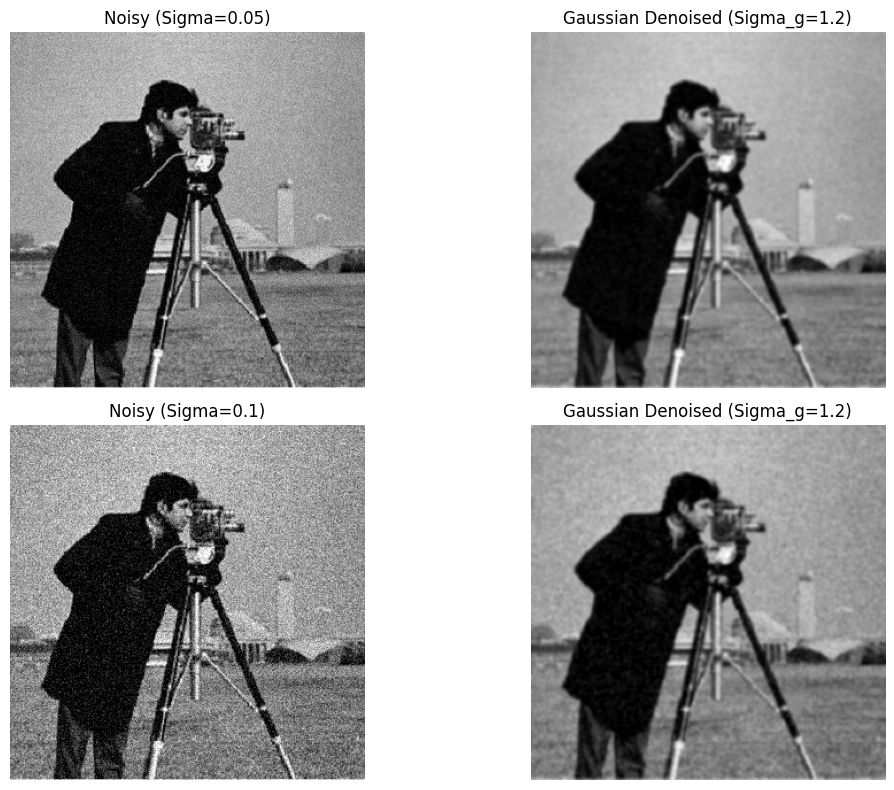

In [ ]:
# Run the code and display the denoising for different Sigmas
plt.figure(figsize=(12, 8))

for i, sn in enumerate(sigmaNoise):
    # Create Noise
    noise = sn * np.random.randn(*f.shape)
    g = f + noise
    
    # Apply Filter
    f_hat = ApplyGaussianFilter(g, sigmaG)
    
    # Plot Noisy vs Denoised
    plt.subplot(2, 2, i*2 + 1)
    plt.imshow(np.clip(g, 0, 1), cmap='gray')
    plt.title(f"Noisy (Sigma={sn})")
    plt.axis('off')
    
    plt.subplot(2, 2, i*2 + 2)
    plt.imshow(np.clip(f_hat, 0, 1), cmap='gray')
    plt.title(f"Gaussian Denoised (Sigma_g={sigmaG})")
    plt.axis('off')

plt.tight_layout()
plt.show()